# **Final model result**

In [1]:
# Imports
from pathlib import Path
import json
import re
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from jiwer import cer, wer

In [2]:
# Imports for model
import torch
import torchaudio
import torchaudio.transforms as T
import torch.nn as nn
from tokenizer import TokenizerBPE01
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import pickle as pkl
import json

# CTC
from ctc_utils import *

# Models
from models import models

from datasets import load_dataset

d:\workplace\Project\parts\STT\ctc_ver01\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
ROOT_DIR = Path(os.getcwd())

VOCAB_DIRS = ROOT_DIR / "trained_models/final/vocab"

MODEL_INFO_JSON = ROOT_DIR / "models_config.json"
MODEL_NO = 24

MODEL_PATH = os.path.join(VOCAB_DIRS, "deep_bilstm", "model24.pt")
TOK_PATH = os.path.join(ROOT_DIR, "vocab.json")
NORMALIZER_PATH = os.path.join(ROOT_DIR, "normalizer1.pkl")

# Continued train result
RESULT_PATH = os.path.join(ROOT_DIR, "trained_models", "final", "vocab", "deep_bilstm", "results_model24.csv")

In [4]:
results = pd.read_csv(RESULT_PATH)
results.shape

(28, 3)

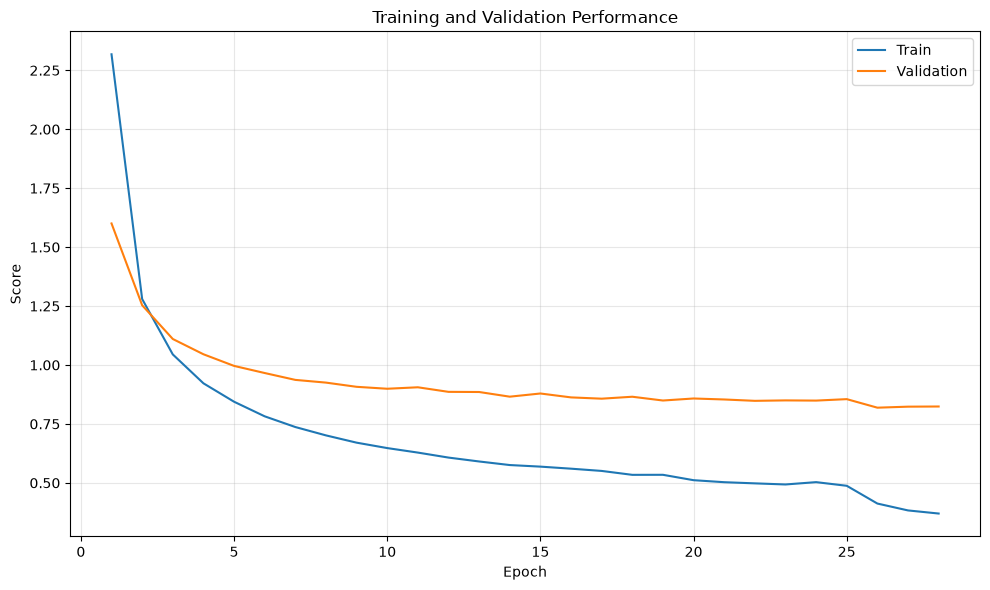

In [5]:
plt.figure(figsize=(10, 6))

plt.plot(
    results["Epoch"],
    results["Train"],
    label="Train"
)

plt.plot(
    results["Epoch"],
    results["Validation"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Training and Validation Performance")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [6]:
# Error testing
# Loading validation data
train_set = load_dataset(
    "openslr/librispeech_asr",
    "clean",
    split="train.100"
)

val_set = load_dataset(
    "openslr/librispeech_asr",
    "clean",
    split="validation"
)

test_set = load_dataset(
    "openslr/librispeech_asr",
    "clean",
    split="test"
)
print()


# Device
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Device:", device)
print()

'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/openslr/librispeech_asr/resolve/71cacbfb7e2354c4226d01e70d77d5fca3d04ba1/librispeech_asr.py
Retrying in 1s [Retry 1/5].
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/openslr/librispeech_asr/resolve/71cacbfb7e2354c4226d01e70d77d5fca3d04ba1/librispeech_asr.py
Retrying in 2s [Retry 2/5].
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/openslr/librispeech_asr/resolve/71cacbfb7e2354c4226d01e70d77d5fca3d04ba1/librispeech_asr.py
Retrying in 4s [Retry 3/5].
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/openslr/librispeech_asr/resolve/71cacbfb7e2354c4226d01e70d77d5fca3d04ba1/librispeech_asr.py
Retrying in 8s [Retry 4/5].
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/openslr/librispeech_asr/resolve/71cacbfb


Device: cpu



In [7]:
add_blank = ['<Blank>']

tokenizer = TokenizerBPE01()
tokenizer.loadFromJSON(TOK_PATH)
tokenizer.update(add_blank)
blank_id = tokenizer.vocab['<Blank>']
pad_id = len(tokenizer.vocab)



Initiate vocabulary of length: 38
Loaded.
Added 1/1 into vocabulary.
Existed: 0/1.
Current vocabulary length: 39


In [8]:
mfcc_transform = torchaudio.transforms.MFCC(
    sample_rate=16000,
    n_mfcc=13,
    melkwargs={
        "n_fft": 1200,
        "win_length": 1200, # 75ms timeframe
        "hop_length": 600,  
        "n_mels": 40
    }
    )

In [9]:
# Data preparation
# Normalizer
class Normalize:
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, x):
        return (x - self.mean) / (self.std + 1e-8)

    def to(self, device):
        self.mean = self.mean.to(device)
        self.std = self.std.to(device)

with open(ROOT_DIR / "normalizer1.pkl", "rb") as f:
    normalizer = pkl.load(f)
    normalizer.to(device) 


def get_input_and_target(dataset):
    # Input output
    input_audios = dataset['audio']
    target_sentences = dataset['text']

    return input_audios, target_sentences


def preprocess_audio(audio, mfcc_transform, device):
    try:
        input_audio = torch.tensor(audio)
    except:
        # For codec-style input
        input_audio = torch.tensor(audio["array"])

    mfccs = mfcc_transform(input_audio).to(device).transpose(0, 1)

    seq_len = len(mfccs)

    return mfccs, seq_len

In [10]:
audios_tr, targets_tr = get_input_and_target(train_set)
audios_val, targets_val = get_input_and_target(val_set)
audios_te, targets_te = get_input_and_target(test_set)
del test_set, train_set, val_set

In [11]:
# Models loading
# Model 1
with open('models_config.json', 'r') as file:
    cfg = json.load(file)

model = cfg[str(24)]
model_no = model["model_no"]
model_type = model["model_type"]
model_parameters = model["model_parameters"]

model = models[model_type](
    input_size=13,
    output_size=len(tokenizer.vocab),
    **model_parameters
).to(device)

model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device)
)

<All keys matched successfully>

In [12]:
results = {
    "Train": {
        "wer": [],
        "cer": []
    },

    "Validation": {
        "wer": [],
        "cer": []
    },

    "Test": {
        "wer": [],
        "cer": []
    }
}

# Train
for audio, target in zip(audios_tr, targets_tr):

    # Preprocess
    mfccs = preprocess_audio(audio, mfcc_transform, device)[0]

    # Inference
    with torch.no_grad():
        logits1 = model(normalizer(mfccs).unsqueeze(0))
        output1, _ = beam_search(logits1, 10, blank_id)

    # Decode
    prediction = tokenizer.tokenToWords(collpase(output1[0], blank_id))

    # Metrics
    wer_tr = wer(target.lower(), prediction)
    cer_tr = cer(target.lower(), prediction)

    # Save
    results["Train"]["wer"].append(wer_tr)
    results["Train"]["cer"].append(cer_tr)
    


# Validation
for audio, target in zip(audios_val, targets_val):

    # Preprocess
    mfccs = preprocess_audio(audio, mfcc_transform, device)[0]

    # Inference
    with torch.no_grad():
        logits1 = model(normalizer(mfccs).unsqueeze(0))
        output1, _ = beam_search(logits1, 10, blank_id)

    # Decode
    prediction = tokenizer.tokenToWords(collpase(output1[0], blank_id))

    # Metrics
    wer_val = wer(target.lower(), prediction)
    cer_val = cer(target.lower(), prediction)

    # Save
    results["Validation"]["wer"].append(wer_val)
    results["Validation"]["cer"].append(cer_val)



# Test
for audio, target in zip(audios_te, targets_te):

    # Preprocess
    mfccs = preprocess_audio(audio, mfcc_transform, device)[0]

    # Inference
    with torch.no_grad():
        logits1 = model(normalizer(mfccs).unsqueeze(0))
        output1, _ = beam_search(logits1, 10, blank_id)

    # Decode
    prediction = tokenizer.tokenToWords(collpase(output1[0], blank_id))

    # Metrics
    wer_te = wer(target.lower(), prediction)
    cer_te = cer(target.lower(), prediction)

    # Save
    results["Test"]["wer"].append(wer_te)
    results["Test"]["cer"].append(cer_te)



In [13]:
def make_report(results):
    report = []

    for model_name, metrics in results.items():

        wer = np.array(metrics["wer"], dtype=float)
        cer = np.array(metrics["cer"], dtype=float)

        report.append({
            "Model": model_name,

            "Samples": len(wer),

            "WER Mean": wer.mean(),
            "WER Median": np.median(wer),
            "WER Std": wer.std(),
            "WER P25": np.percentile(wer, 25),
            "WER P75": np.percentile(wer, 75),
            "WER Min": wer.min(),
            "WER Max": wer.max(),

            "CER Mean": cer.mean(),
            "CER Median": np.median(cer),
            "CER Std": cer.std(),
            "CER P25": np.percentile(cer, 25),
            "CER P75": np.percentile(cer, 75),
            "CER Min": cer.min(),
            "CER Max": cer.max(),
        })

    return pd.DataFrame(report)


report = make_report(results)

print(report.to_string(index=False))

     Model  Samples  WER Mean  WER Median  WER Std  WER P25  WER P75  WER Min  WER Max  CER Mean  CER Median  CER Std  CER P25  CER P75  CER Min  CER Max
     Train    28539  0.369486    0.365854 0.144567 0.272727 0.461538      0.0    1.175  0.112685    0.106195 0.055387 0.074627 0.144279      0.0 0.500000
Validation     2703  0.579199    0.571429 0.199349 0.454545 0.700000      0.0    2.000  0.220286    0.206897 0.099343 0.152542 0.274767      0.0 0.772727
      Test     2620  0.564799    0.555556 0.202545 0.433333 0.684586      0.0    2.000  0.215666    0.204360 0.098462 0.148148 0.268830      0.0 0.714286
